Nama: Nicholas Kisu Candra

Program: AI Development

**0. Import module yang diperlukan**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**1. Membaca data**


> Silakan gunakan teknik membaca data teratas dan terbawah (cth: head(), tail()) yang tersedia pada pandas, atau teknik lainnya seperti describe()



In [4]:
# load dataset
df = pd.read_csv("Housing.csv")

# lihat data atas
df.head()

# lihat data bawah
df.tail()

# statistik deskriptif
df.describe()

# info tipe data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


Insight :

Dataset Housing terdiri dari 545 data rumah dengan 13 variabel (kolom) yang menggambarkan karakteristik properti.

Tipe data pada dataset terdiri dari:

6 kolom numerik (int64) → seperti price, area, bedrooms, bathrooms, stories, parking
7 kolom kategorikal (string) → seperti mainroad, guestroom, basement, airconditioning, prefarea, dan furnishingstatus

Kolom price merupakan variabel target yang menunjukkan harga rumah, sedangkan kolom lain merupakan faktor yang dapat mempengaruhi harga, seperti luas rumah, jumlah kamar, serta fasilitas yang tersedia.

Tidak terdapat missing value karena semua kolom memiliki jumlah data yang sama yaitu 545 non-null entries. Hal ini menunjukkan dataset cukup lengkap dan siap digunakan untuk analisis lebih lanjut tanpa perlu penanganan missing value pada tahap awal.

Selain itu, terdapat beberapa kolom kategorikal yang berisi nilai seperti yes/no yang kemungkinan perlu dikonversi ke bentuk numerik agar dapat digunakan dalam analisis statistik atau correlation matrix.


**2. Cek Missing values dan duplicate pada data**
> Cek apakah ada missing values / duplicate pada data, jika ada perbaiki, jika tidak ada, berikan insight/penjelasan.

In [ ]:
# cek missing value
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
# cek jumlah data duplikat
df.duplicated().sum()

np.int64(0)

Insight :

Berdasarkan pengecekan missing values, tidak ditemukan nilai kosong pada dataset. Setiap kolom memiliki jumlah data yang lengkap sehingga tidak diperlukan proses pengisian missing value.

Selain itu, hasil pengecekan duplicate menunjukkan tidak terdapat data yang duplikat. Hal ini menunjukkan bahwa dataset sudah bersih dan tidak memerlukan proses penghapusan data ganda.

Dataset dapat langsung digunakan untuk tahap analisis berikutnya karena tidak memiliki permasalahan missing value maupun duplicate.


**3. Hapus data jika ada duplicate dan isi missing values jika ada**

In [9]:
# hapus duplicate jika ada
df = df.drop_duplicates()

# cek jumlah data setelah hapus duplicate
df.shape

(545, 13)

In [10]:
# isi missing value numerik dengan mean
df = df.fillna(df.mean(numeric_only=True))

# cek kembali missing value
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Insight :

Berdasarkan hasil pengecekan sebelumnya, dataset tidak memiliki data duplikat maupun missing value. Oleh karena itu, proses penghapusan duplicate dan pengisian missing value tidak mengubah jumlah data.

Dataset sudah dalam kondisi bersih sehingga dapat langsung digunakan untuk analisis lebih lanjut tanpa perlu proses data cleaning tambahan.


**4. Transformasi format**

> Cek dataset, apakah ada data yang bisa ditransformasi? (cth : yes or no menjadi 1 dan 0)

In [12]:
# Cek kolom kategorikal

df.select_dtypes(include="object").head()

/tmp/ipykernel_39924/3784866787.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").head()


,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,yes,no,yes,no,furnished


In [13]:
# Ubah yes/no menjadi 1/0

df = df.replace({
    "yes": 1,
    "no": 0
})

In [14]:
# Ubah furnishingstatus menjadi numerik

df["furnishingstatus"] = df["furnishingstatus"].replace({
    "unfurnished": 0,
    "semi-furnished": 1,
    "furnished": 2
})

In [16]:
# Cek hasil transformasi
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


In [17]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

Insight :

Dataset memiliki beberapa variabel kategorikal dengan nilai yes/no seperti:

- mainroad
- guestroom
- basement
- hotwaterheating
- airconditioning
- prefarea

Selain itu, terdapat variabel furnishingstatus yang berisi kategori:

- furnished
- semi-furnished
- unfurnished

Agar data dapat dianalisis menggunakan metode statistik dan correlation matrix, variabel kategorikal tersebut ditransformasi menjadi bentuk numerik.

Nilai yes/no diubah menjadi:

- yes = 1
- no = 0

Sedangkan furnishingstatus diubah menjadi skala numerik:

- unfurnished = 0
- semi-furnished = 1
- furnished = 2

Setelah transformasi, seluruh fitur dalam dataset menjadi numerik sehingga memudahkan proses analisis, visualisasi, dan perhitungan korelasi antar variabel.

Transformasi ini penting karena sebagian besar metode analisis data hanya dapat memproses data dalam bentuk numerik.


**5. Laksanakan EDA (Exploratory Data Analysis)**

> Pada tahap ini, lakukan visualisasi data, dan eksplorasi serta analisis dataset yang diberikan sesuai EDA, lalu berikan setidaknya 3 insight dari dataset tersebut. Silakan tambah cell sebanyak - banyak yang diperlukan untuk keperluan EDA atau visualisasi data.

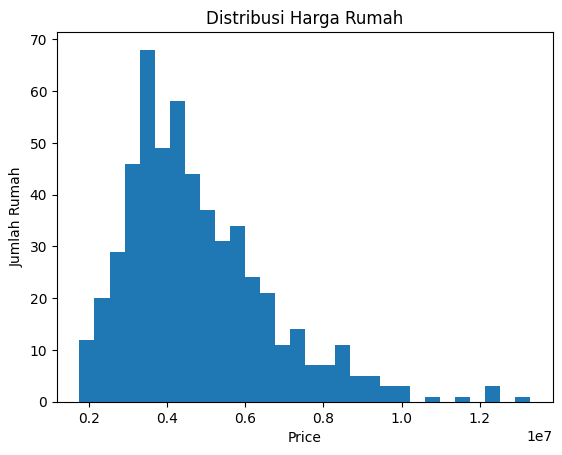

In [18]:
# Distribusi Harga Rumah
plt.figure()

plt.hist(df["price"], bins=30)

plt.title("Distribusi Harga Rumah")
plt.xlabel("Price")
plt.ylabel("Jumlah Rumah")

plt.show()

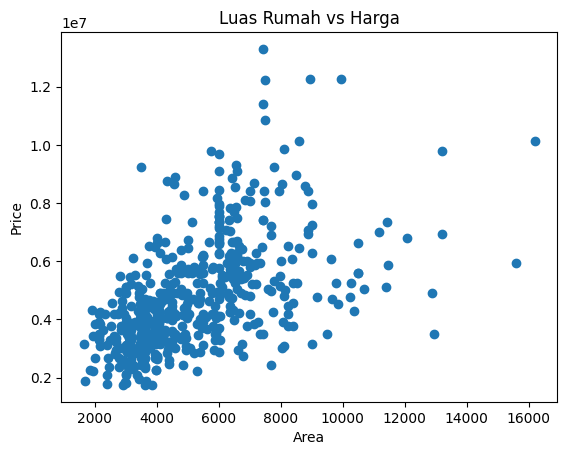

In [19]:
# Hubungan luas rumah dengan harga

plt.figure()

plt.scatter(df["area"], df["price"])

plt.title("Luas Rumah vs Harga")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

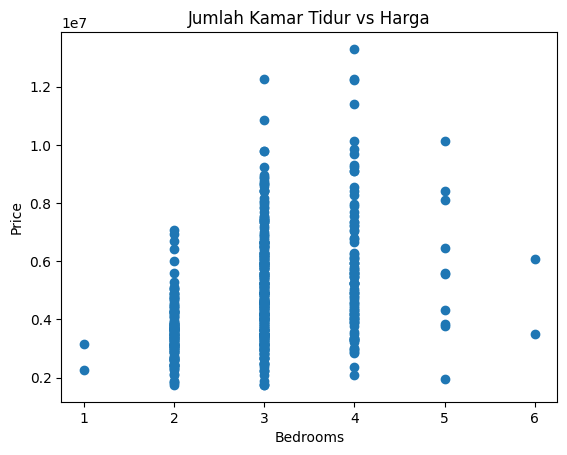

In [20]:
# Jumlah kamar tidur vs harga

plt.figure()

plt.scatter(df["bedrooms"], df["price"])

plt.title("Jumlah Kamar Tidur vs Harga")
plt.xlabel("Bedrooms")
plt.ylabel("Price")

plt.show()

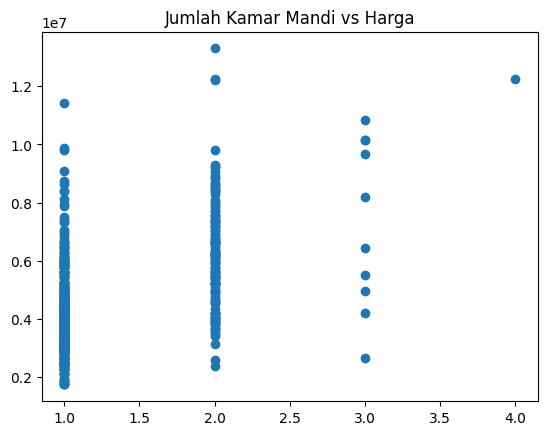

In [21]:
# Jumlah kamar mandi vs harga

plt.figure()

plt.scatter(df["bathrooms"], df["price"])

plt.title("Jumlah Kamar Mandi vs Harga")

plt.show()

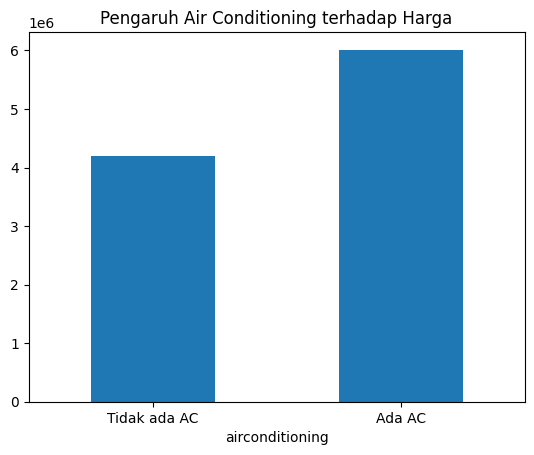

In [22]:
# Pengaruh AC terhadap rumah
plt.figure()

df.groupby("airconditioning")["price"].mean().plot(kind="bar")

plt.title("Pengaruh Air Conditioning terhadap Harga")

plt.xticks([0,1], ["Tidak ada AC","Ada AC"], rotation=0)

plt.show()

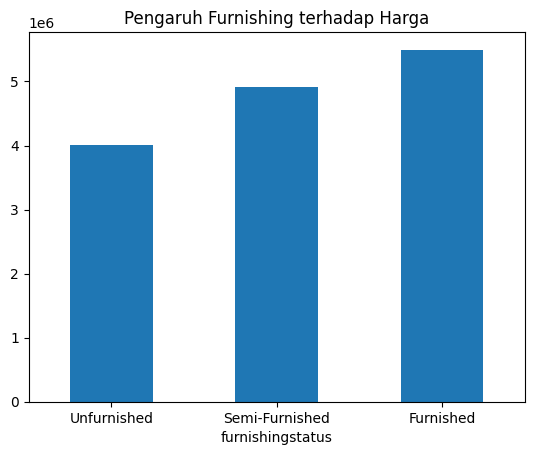

In [23]:
# Pengaruh furnishing terhadap harga

plt.figure()

df.groupby("furnishingstatus")["price"].mean().plot(kind="bar")

plt.title("Pengaruh Furnishing terhadap Harga")

plt.xticks(
    [0,1,2],
    ["Unfurnished","Semi-Furnished","Furnished"],
    rotation=0
)

plt.show()

Insight :

- Distribusi harga rumah menunjukkan variasi harga yang cukup besar, yang menandakan adanya perbedaan karakteristik rumah dalam dataset.
- Luas rumah (area) memiliki hubungan positif dengan harga. Rumah dengan luas lebih besar cenderung memiliki harga yang lebih tinggi.
- Jumlah kamar tidur dan kamar mandi juga berpengaruh terhadap harga rumah. Semakin banyak kamar, harga rumah cenderung meningkat.
- Rumah yang memiliki air conditioning cenderung memiliki harga rata-rata lebih tinggi dibanding rumah tanpa air conditioning.
- Status furnishing juga mempengaruhi harga rumah. Rumah yang furnished memiliki harga rata-rata lebih tinggi dibanding semi-furnished dan unfurnished.


**6. Correlation Matrix**

> Buat correlation matrix, transformasi dulu seluruh data ke numerik agar tidak error saat masuk ke correlation matrix. Lalu berikan insight, apa yang kamu temukan dari correlation matrix dataset tersebut?

In [24]:
# ambil semua kolom numerik
numeric_df = df.select_dtypes(include=["int64","float64"])

# hitung korelasi
corr_matrix = numeric_df.corr()

corr_matrix

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


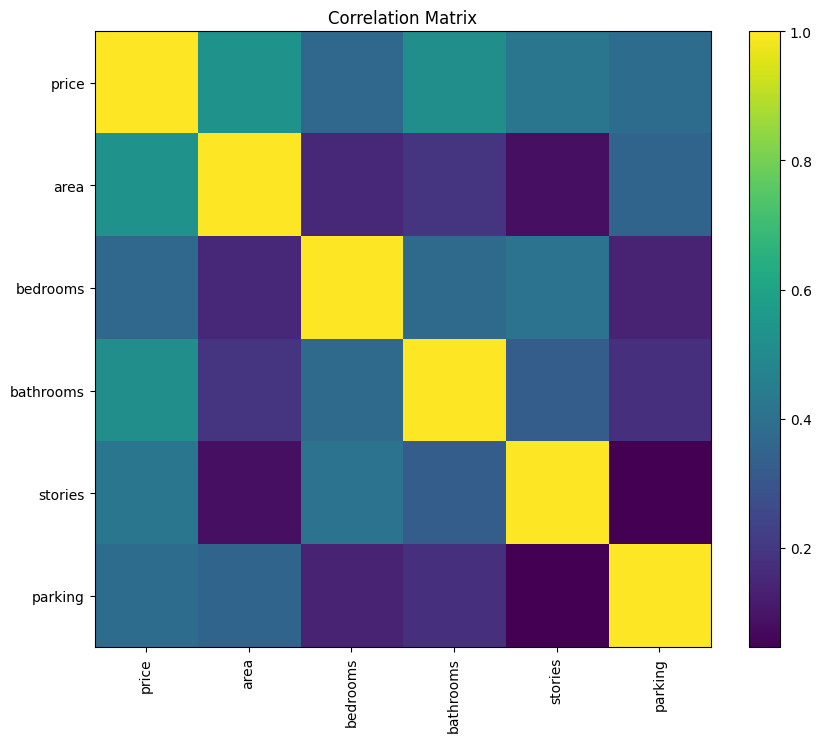

In [26]:
plt.figure(figsize=(10,8))

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Matrix")

plt.show()

Insight :

1. Luas rumah (area) memiliki hubungan cukup kuat dengan harga

Terlihat bahwa area memiliki korelasi positif paling tinggi terhadap price dibanding variabel numerik lainnya.

Artinya:

> semakin luas ukuran rumah, maka harga rumah cenderung semakin tinggi.

Hal ini masuk akal karena rumah yang lebih besar biasanya memiliki nilai jual lebih tinggi.

---

2. Jumlah kamar mandi memiliki pengaruh terhadap harga

Variabel bathrooms juga menunjukkan korelasi positif terhadap price.

Artinya:

> rumah dengan jumlah kamar mandi lebih banyak cenderung memiliki harga lebih mahal.

Hal ini menunjukkan bahwa fasilitas rumah mempengaruhi nilai properti.

---

3. Jumlah kamar tidur memiliki pengaruh sedang terhadap harga

Korelasi antara bedrooms dan price terlihat cukup positif meskipun tidak sekuat area.

Artinya:

> semakin banyak kamar tidur, harga rumah cenderung meningkat, tetapi pengaruhnya tidak sebesar luas rumah.

---

4. Jumlah lantai dan parkir memiliki pengaruh lebih kecil

Variabel stories dan parking memiliki korelasi yang lebih rendah terhadap price dibanding variabel lainnya.

Artinya:

> jumlah lantai dan kapasitas parkir tetap berpengaruh, tetapi tidak sebesar luas rumah atau jumlah kamar mandi.


**7. Feature Engineering**



> Laksanakan Feature Engineering, buat variabel baru berdasarkan variabel yang sudah ada. Analisis hasil dari variabel baru tersebut.



In [27]:
# membuat fitur baru
df["price_per_area"] = df["price"] / df["area"]

df[["price","area","price_per_area"]].head()

,price,area,price_per_area
0,13300000,7420,1792.452830
1,12250000,8960,1367.187500
2,12250000,9960,1229.919679
3,12215000,7500,1628.666667
4,11410000,7420,1537.735849


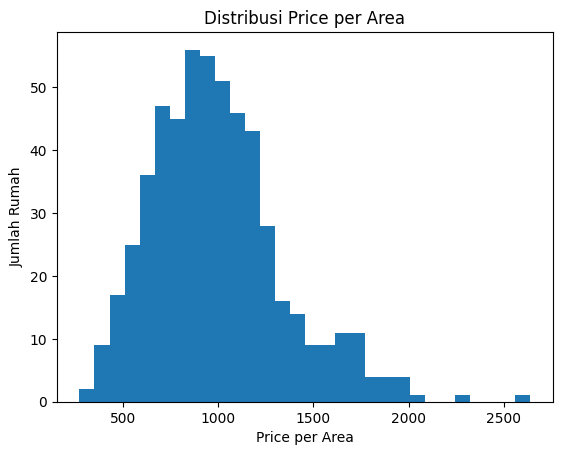

In [28]:
plt.figure()

plt.hist(df["price_per_area"], bins=30)

plt.title("Distribusi Price per Area")
plt.xlabel("Price per Area")
plt.ylabel("Jumlah Rumah")

plt.show()

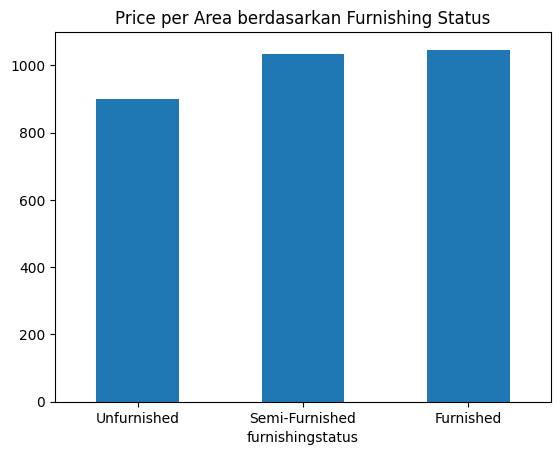

In [29]:
plt.figure()

df.groupby("furnishingstatus")["price_per_area"].mean().plot(kind="bar")

plt.title("Price per Area berdasarkan Furnishing Status")

plt.xticks(
    [0,1,2],
    ["Unfurnished","Semi-Furnished","Furnished"],
    rotation=0
)

plt.show()

Insight :

Fitur baru price_per_area menunjukkan harga rumah dibandingkan dengan luas rumah. Variabel ini membantu melihat apakah suatu rumah memiliki harga yang tinggi atau rendah relatif terhadap ukurannya.

Distribusi price per area menunjukkan bahwa nilai harga rumah bervariasi meskipun luas rumah berbeda. Selain itu, rumah dengan furnishing lebih lengkap cenderung memiliki price per area yang lebih tinggi dibanding rumah yang tidak memiliki furnitur.

Feature engineering membantu menghasilkan informasi tambahan yang tidak langsung terlihat dari data asli.


**8. Kesimpulan**
> Berikan kesimpulan untuk dataset ini dan hasil dari analisis anda terhadap dataset yang dipakai.

TLDR:

> Berdasarkan EDA, harga rumah dipengaruhi oleh luas rumah, jumlah kamar, dan fasilitas yang tersedia. Luas rumah memiliki pengaruh paling besar terhadap harga. Fasilitas seperti AC, parking, dan furnishing juga berkontribusi terhadap kenaikan harga rumah. Feature engineering menghasilkan variabel price per area yang membantu melihat nilai rumah relatif terhadap ukurannya. Secara keseluruhan, ukuran dan fasilitas rumah merupakan faktor utama yang mempengaruhi harga properti.

---

Berdasarkan hasil Exploratory Data Analysis (EDA), dapat disimpulkan bahwa harga rumah dipengaruhi oleh beberapa faktor utama seperti luas rumah, jumlah kamar, jumlah kamar mandi, dan fasilitas yang tersedia. Variabel luas rumah (area) memiliki pengaruh paling besar terhadap harga, dimana semakin luas rumah maka harga cenderung semakin tinggi.

Selain itu, jumlah kamar tidur dan kamar mandi juga memiliki hubungan positif terhadap harga rumah. Rumah dengan fasilitas tambahan seperti air conditioning, parking, dan lokasi di area yang diinginkan (prefarea) cenderung memiliki harga yang lebih tinggi dibanding rumah tanpa fasilitas tersebut.

Hasil correlation matrix menunjukkan bahwa beberapa variabel seperti area, bathrooms, dan bedrooms memiliki korelasi positif terhadap harga rumah, yang menunjukkan bahwa faktor ukuran dan kenyamanan rumah mempengaruhi nilai properti.

Melalui feature engineering, dibuat variabel baru yaitu price per area yang membantu melihat nilai rumah berdasarkan perbandingan harga terhadap luas rumah. Variabel ini memberikan perspektif tambahan dalam menganalisis apakah suatu rumah tergolong mahal atau murah dibanding ukurannya.

Secara keseluruhan, dataset menunjukkan bahwa karakteristik fisik rumah dan fasilitas yang tersedia berperan penting dalam menentukan harga rumah. Analisis ini dapat digunakan sebagai dasar untuk memahami faktor-faktor yang mempengaruhi harga properti.